<a href="https://colab.research.google.com/github/nehasingh913833-gif/basic-ML/blob/main/1D_CNBN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn
import numpy as np
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_development_fmri, fetch_atlas_msdl
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)



Loading data and extracting time series...


[fetch_development_fmri] Dataset directory found: /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset directory found: /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Dataset directory found: /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3f12286e80016c3c37e/ ...

...

[fetch_atlas_msdl] Dataset created in /root/nilearn_data/msdl_atlas

[fetch_atlas_msdl] Downloading data from https://team.inria.fr/parietal/files/2015/01/MSDL_rois.zip ...

[fetch_atlas_msdl]  ...done. (1 seconds, 0 min)

[fetch_atlas_msdl] Extracting data from 
/root/nilearn_data/msdl_atlas/dedd5c670ed1fd457a722109d3c7f958/MSDL_rois.zip...

[fetch_atlas_msdl] .. done.

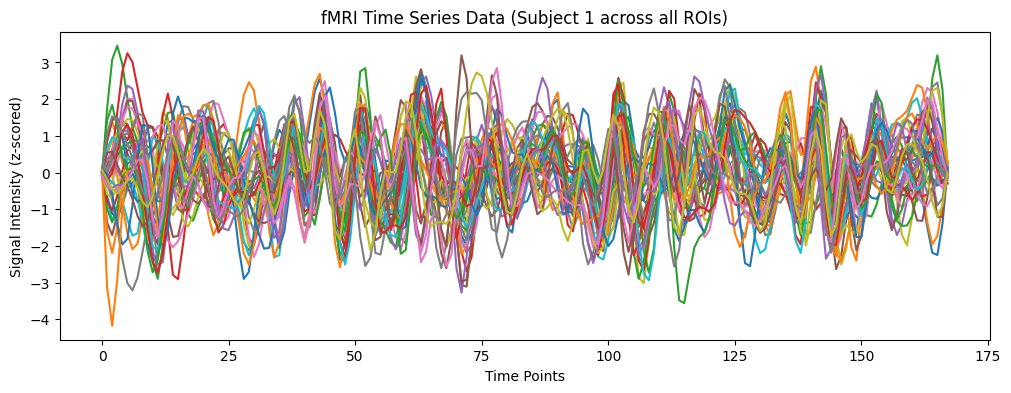

Calculating Pearson Correlations...


<Figure size 700x600 with 0 Axes>

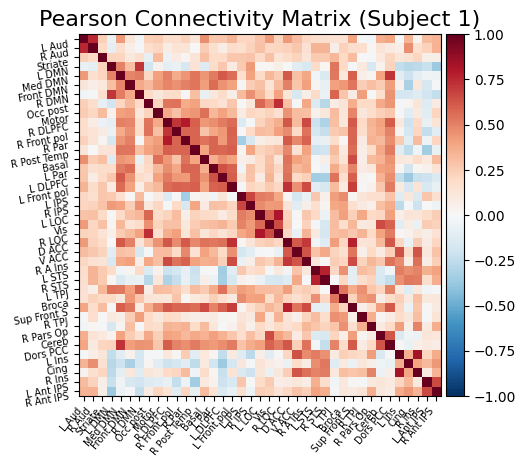

In [ ]:
# 1. LOAD DATA & EXTRACT TIME SERIES

print("Loading data and extracting time series...")
development_dataset = fetch_development_fmri(n_subjects=60)
msdl_data = fetch_atlas_msdl()

masker = NiftiMapsMasker(
    maps_img=msdl_data.maps,
    resampling_target="data",
    t_r=development_dataset.t_r,
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    standardize="zscore_sample",
    standardize_confounds=True,
    verbose=0
)

# List of 2D arrays: (time_steps, regions)
time_series_data = list(map(masker.fit_transform, development_dataset.func, development_dataset.confounds))


# PLOT 1: TIME SERIES (For Subject 1)

plt.figure(figsize=(12, 4))
plt.plot(time_series_data[0])
plt.title('fMRI Time Series Data (Subject 1 across all ROIs)')
plt.xlabel('Time Points')
plt.ylabel('Signal Intensity (z-scored)')
plt.show()


# 2. CONNECTIVITY MATRIX (PEARSON)

print("Calculating Pearson Correlations...")


# PLOT 2: 2D CONNECTIVITY MATRIX (For Subject 1)

# We use vectorize=False temporarily just to get the 2D grid for plotting
conn_matrix_2d = ConnectivityMeasure(kind='correlation', vectorize=False, standardize='zscore_sample')
subject1_matrix = conn_matrix_2d.fit_transform([time_series_data[0]])[0]

plt.figure(figsize=(7, 6))
plotting.plot_matrix(
    subject1_matrix,
    labels=msdl_data.labels,
    colorbar=True, vmax=1, vmin=-1,
    title="Pearson Connectivity Matrix (Subject 1)"
)
plt.show()


# DATA PREP: FLATTEN FOR 1D CNN

# We use vectorize=True to flatten the lower-triangle into a 1D vector for the neural network
connectivity_1d = ConnectivityMeasure(kind='correlation', vectorize=True, standardize='zscore_sample')
X_flattened = connectivity_1d.fit_transform(time_series_data)

# Expand dimensions so shape becomes (60, 741, 1) for the 1D CNN
X_cnn1d = np.expand_dims(X_flattened, axis=-1)

# Encode Labels (Child_Adult)
y_raw = development_dataset.phenotypic['Child_Adult']
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)




In [ ]:
# 3. BUILD 1D CNN ARCHITECTURE

def create_1d_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=16, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model




In [ ]:
# 4. SINGLE CROSS VALIDATION & TRAINING

print("Training 1D CNN...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_histories = [] # Stores training history for the final plot
metrics = {'accuracy': [], 'precision': [], 'sensitivity': [], 'specificity': [], 'f1': [], 'auc': []}

for fold, (train_idx, test_idx) in enumerate(cv.split(X_cnn1d, y_encoded)):
    X_train, X_test = X_cnn1d[train_idx], X_cnn1d[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    model = create_1d_cnn(input_shape=(X_cnn1d.shape[1], 1))

    # Train the model and save the history
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=8,
        validation_data=(X_test, y_test),
        verbose=0
    )
    all_histories.append(history.history)

    # Generate Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

    # Calculate Metrics
    metrics['accuracy'].append(accuracy_score(y_test, y_pred_classes))
    metrics['precision'].append(precision_score(y_test, y_pred_classes, zero_division=0))
    metrics['sensitivity'].append(recall_score(y_test, y_pred_classes, zero_division=0))
    metrics['f1'].append(f1_score(y_test, y_pred_classes, zero_division=0))

    try:
        metrics['auc'].append(roc_auc_score(y_test, y_pred_probs))
    except ValueError:
        metrics['auc'].append(np.nan)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_classes, labels=[0, 1]).ravel()
    metrics['specificity'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    print(f"Fold {fold+1} processed.")

# Print Averages
print("\n===================================")
print("FINAL RESULTS (MEAN ± SD)")
print("===================================")
print(f"Accuracy    : {np.mean(metrics['accuracy']):.4f} ± {np.std(metrics['accuracy']):.4f}")
print(f"Precision   : {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
print(f"Sensitivity : {np.mean(metrics['sensitivity']):.4f} ± {np.std(metrics['sensitivity']):.4f}")
print(f"Specificity : {np.mean(metrics['specificity']):.4f} ± {np.std(metrics['specificity']):.4f}")
print(f"F1 Score    : {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"AUC Score   : {np.nanmean(metrics['auc']):.4f} ± {np.nanstd(metrics['auc']):.4f}")




Training 1D CNN...
Fold 1 processed.
Fold 2 processed.
Fold 3 processed.
Fold 4 processed.


Fold 5 processed.

FINAL RESULTS (MEAN ± SD)
Accuracy    : 0.7833 ± 0.0408
Precision   : 0.7967 ± 0.0609
Sensitivity : 0.9800 ± 0.0400
Specificity : 0.1000 ± 0.2000
F1 Score    : 0.8761 ± 0.0234
AUC Score   : 0.9033 ± 0.0877


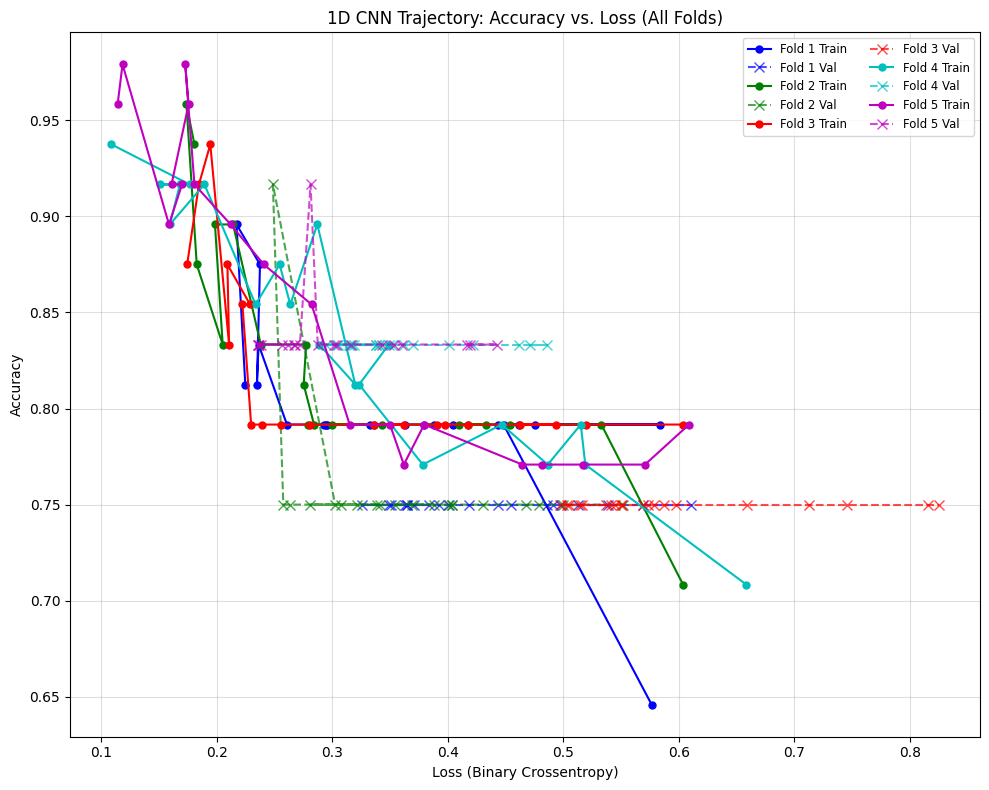

In [ ]:
# PLOT 3: ACCURACY VS. LOSS (ALL FOLDS IN ONE GRAPH)

plt.figure(figsize=(10, 8))
colors = ['b', 'g', 'r', 'c', 'm'] # Unique color for each fold

for i, hist in enumerate(all_histories):
    # Training Trajectory (solid line, circle markers)
    plt.plot(hist['loss'], hist['accuracy'],
             color=colors[i], marker='o', markersize=5, linestyle='-',
             label=f'Fold {i+1} Train')

    # Validation Trajectory (dashed line, X markers)
    plt.plot(hist['val_loss'], hist['val_accuracy'],
             color=colors[i], marker='x', markersize=7, linestyle='--', alpha=0.7,
             label=f'Fold {i+1} Val')

plt.title('1D CNN Trajectory: Accuracy vs. Loss (All Folds)')
plt.xlabel('Loss (Binary Crossentropy)')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.4)
plt.legend(loc='best', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()